In [ ]:
# Fake News Detection Using Machine Learning
# AI/ML Project
#
# Dataset: WELFake Dataset
# Model: Logistic Regression
# Feature Extraction: TF-IDF

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("dataset/WELFake_Dataset.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 72134
Number of columns: 4


In [3]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [4]:
df.tail()

,Unnamed: 0,title,text,label
72129,72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0
72133,72133,Goldman Sachs Endorses Hillary Clinton For Pre...,Goldman Sachs Endorses Hillary Clinton For Pre...,1


In [6]:
df.shape

(72134, 4)

In [7]:
df.dtypes

Unnamed: 0     int64
title         object
text          object
label          int64
dtype: object

In [9]:
df= df.drop(columns='Unnamed: 0', axis=1)

In [10]:
df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   71576 non-null  object
 1   text    72095 non-null  object
 2   label   72134 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [14]:
df.duplicated().sum(
    
)

np.int64(0)

In [13]:
df = df.drop_duplicates()

In [17]:
df.isnull().sum()

title    0
text     0
label    0
dtype: int64

In [16]:
df = df.dropna(subset=["title", "text", "label"])

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (63121, 3)


# EDA

In [ ]:
df['label'].value_counts()   
# 0 = Fake
# 1 = Real

label
0    34791
1    28330
Name: count, dtype: int64

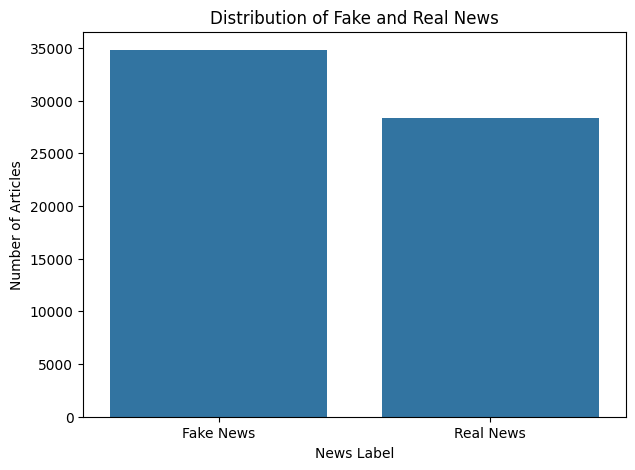

In [21]:
plt.figure(figsize=(7, 5))

sns.countplot(x="label", data=df)

plt.title("Distribution of Fake and Real News")
plt.xlabel("News Label")
plt.ylabel("Number of Articles")

plt.xticks(
    [0, 1],
    ["Fake News", "Real News"]
)

plt.show()

In [22]:

label_percentage = df["label"].value_counts(normalize=True) * 100

print("Fake News:", round(label_percentage[0], 2), "%")
print("Real News:", round(label_percentage[1], 2), "%")

Fake News: 55.12 %
Real News: 44.88 %


In [23]:
df["content"] = (
    df["title"].astype(str) + " " +
    df["text"].astype(str)
)

df[["title", "text", "content", "label"]].head()

,title,text,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",SATAN 2: Russia unvelis an image of its terrif...,1
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,About Time! Christian Group Sues Amazon and SP...,1


In [24]:
df["text_length"] = df["content"].apply(len)

df["text_length"].describe()

count     63121.000000
mean       3379.253212
std        3640.945559
min          14.000000
25%        1538.000000
50%        2545.000000
75%        4193.000000
max      143035.000000
Name: text_length, dtype: float64

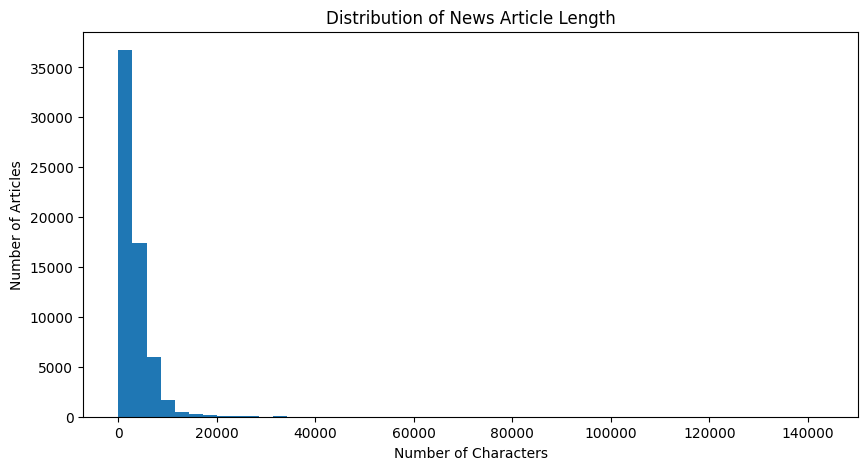

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(df["text_length"], bins=50)

plt.title("Distribution of News Article Length")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Articles")

plt.show()

In [26]:
X = df["content"]
y = df["label"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (63121,)
Target shape: (63121,)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 50496
Testing samples: 12625


In [28]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.7,
    max_features=100000,
    ngram_range=(1, 2)
)

print("TF-IDF Vectorizer created.")

TF-IDF Vectorizer created.


In [29]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (50496, 100000)
Testing TF-IDF shape: (12625, 100000)


# model training

In [30]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Logistic Regression model created.")

Logistic Regression model created.


In [31]:
model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [32]:
y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")

Predictions completed!


In [33]:
precision = precision_score(y_test, y_pred)

print("Precision:", round(precision, 4))

Precision: 0.9491


In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      6959
           1       0.95      0.94      0.95      5666

    accuracy                           0.95     12625
   macro avg       0.95      0.95      0.95     12625
weighted avg       0.95      0.95      0.95     12625



In [35]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[6672  287]
 [ 313 5353]]


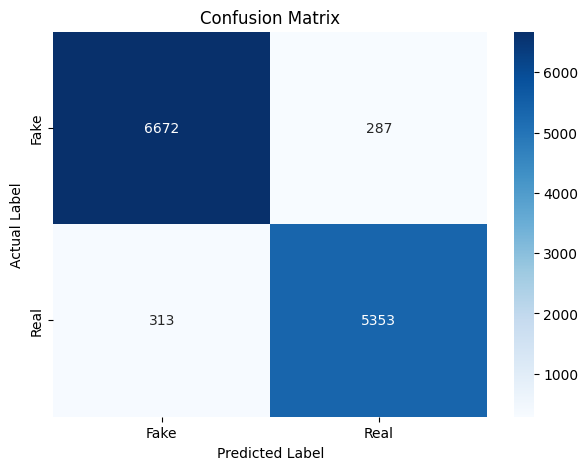

In [36]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [37]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": y_pred[:20]
})

comparison

,Actual,Predicted
0,1,0
1,0,0
2,0,0
3,1,1
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [38]:
sample_news = """
The government announced a new policy today that will affect
millions of citizens across the country.
"""

sample_vector = vectorizer.transform([sample_news])

prediction = model.predict(sample_vector)[0]

if prediction == 1:
    print("Prediction: REAL NEWS")
else:
    print("Prediction: FAKE NEWS")

Prediction: REAL NEWS


In [39]:
probability = model.predict_proba(sample_vector)[0]

print("Fake Probability:", round(probability[0] * 100, 2), "%")
print("Real Probability:", round(probability[1] * 100, 2), "%")

Fake Probability: 13.59 %
Real Probability: 86.41 %


In [40]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)





In [46]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9524752475247524
Precision: 0.9491134751773049
Recall   : 0.9447582068478645
F1 Score : 0.946930833185919
